In [32]:
import numpy as np
import matplotlib.pyplot as plt

## Modules - 1, 2, 3, 4, 5

In [33]:
def calculate_lj_properties(r_sq, r_cutoff_sq):
    """
    Calculates reduced potential energy and force magnitude for a pair of atoms.
    Implements the shifted Lennard-Jones potential: phi(r) - phi(rc).
    Returns (potE, force/r).
    """
    inv_rc2 = 1.0 / r_cutoff_sq
    inv_rc6 = inv_rc2**3
    inv_rc12 = inv_rc6**2
    phi_cut = 4 * (inv_rc12 - inv_rc6)

    inv_r2 = 1.0 / r_sq
    inv_r6 = inv_r2**3
    inv_r12 = inv_r6**2

    phi = 4 * (inv_r12 - inv_r6)

    force_by_r = 48 * inv_r2 * (inv_r12 - 0.5 * inv_r6)
    force_by_rc = 48 * inv_rc2 * (inv_rc12 - 0.5 * inv_rc6)
    force_by_r = force_by_r - force_by_rc
    potE = phi - phi_cut + 0.5 * force_by_rc * (r_sq - r_cutoff_sq)

    return potE, force_by_r


def generate_fcc_lattice(n_cells, rho_star):
    """
    Generates an FCC lattice of atoms.
    Returns (positions array of shape (N,3), box length L).
    N = 4 * n_cells^3.
    """
    L = (4 * n_cells**3 / rho_star) ** (1 / 3)
    a = L / n_cells
    b1 = np.array([0, 0, 0])
    b2 = np.array([a / 2, a / 2, 0])
    b3 = np.array([a / 2, 0, a / 2])
    b4 = np.array([0, a / 2, a / 2])
    positions = []
    for i in range(n_cells):
        for j in range(n_cells):
            for k in range(n_cells):
                cell_origin = np.array([i, j, k]) * (L / n_cells)
                positions.append(cell_origin + b1)
                positions.append(cell_origin + b2)
                positions.append(cell_origin + b3)
                positions.append(cell_origin + b4)
    return np.array(positions), L


def apply_minimum_image(pos_i, pos_j, L):
    """
    Calculates the shortest distance vector between two atoms using
    the minimum image convention. dx, dy, dz are kept in [-L/2, L/2].
    """
    dr = pos_j - pos_i
    dr -= L * np.round(dr / L)
    return dr


def calculate_total_force(pos, box_length, r_cutoff_sq):
    """Returns (total_pe, forces array of shape (N,3))."""
    N = len(pos)
    forces = np.zeros((N, 3))
    dr = apply_minimum_image(pos[:, np.newaxis, :], pos[np.newaxis, :, :], box_length)
    r_sq = np.sum(dr**2, axis=2)
    r_sq = np.triu(r_sq, k=1)
    mask = (r_sq < r_cutoff_sq) & (r_sq > 0)
    pot, force_by_r = np.zeros_like(r_sq), np.zeros_like(r_sq)
    pot[mask], force_by_r[mask] = calculate_lj_properties(r_sq[mask], r_cutoff_sq)
    f_mat = force_by_r[:, :, np.newaxis] * dr
    forces += np.sum(f_mat, axis=0)
    forces -= np.sum(f_mat, axis=1)
    total_pe = np.sum(pot)
    return total_pe, forces


def calculate_kinetic_energy(vel):
    """K* = 0.5 * sum(v²)  [m* = 1 in reduced units]"""
    return 0.5 * np.sum(vel**2)


def update_neighbor_list(pos, L, r_skin_sq):
    """
    Builds a list of atom pairs (i, j) within the skin radius.
    Uses the Minimum Image Convention. Fully vectorized.
    """
    dr = apply_minimum_image(pos[:, np.newaxis, :], pos[np.newaxis, :, :], L)
    r_sq = np.sum(dr**2, axis=2)
    i_idx, j_idx = np.where(np.triu(r_sq < r_skin_sq, k=1))
    return np.stack([i_idx, j_idx], axis=1)


def calculate_forces_optimized(pos, neighbor_pairs, L, r_cutoff_sq):
    """
    Calculates total forces using only the pairs in the neighbor list.
    Returns (total_pe, forces array of shape (N,3)).
    """
    N = len(pos)
    forces = np.zeros((N, 3))
    total_pe = 0.0
    if len(neighbor_pairs) == 0:
        return total_pe, forces

    i_idx = neighbor_pairs[:, 0]
    j_idx = neighbor_pairs[:, 1]

    dr = apply_minimum_image(pos[i_idx], pos[j_idx], L)
    r_sq = np.sum(dr**2, axis=1)

    mask = r_sq < r_cutoff_sq
    pot, force_by_r = calculate_lj_properties(r_sq[mask], r_cutoff_sq)

    f_vec = force_by_r[:, np.newaxis] * dr[mask]
    np.add.at(forces, i_idx[mask], -f_vec)
    np.add.at(forces, j_idx[mask],  f_vec)
    total_pe = np.sum(pot)
    return total_pe, forces


def velocity_verlet_step_opt(pos, vel, force, dt, box_length, r_cutoff_sq, neighbour_list):
    """
    Velocity Verlet step using the optimized neighbor-list force calculation.
    Returns (pos_new, vel_new, pe_new, force_new).
    """
    pos_new = pos + vel * dt + 0.5 * force * dt**2
    pos_new = pos_new % box_length
    vel_mid = vel + 0.5 * force * dt
    pe_new, force_new = calculate_forces_optimized(pos_new, neighbour_list, box_length, r_cutoff_sq)
    vel_new = vel_mid + 0.5 * force_new * dt
    return pos_new, vel_new, pe_new, force_new

def initialize_velocities(N, T_target):
    """
    Assigns initial velocities from a Maxwell-Boltzmann distribution.
    Generates a (N, 3) array with std_dev = sqrt(T_target),
    then removes net momentum so the center-of-mass is stationary.
    """
    sigma = np.sqrt(T_target)
    vel = np.random.normal(loc=0.0, scale=sigma, size=(N, 3))
    vel -= vel.mean(axis=0)  
    return vel

def rescale_velocities ( vel , T_target ) :

    """
    Scales velocities to match the target temperature .
    """
    # 1. Calculate current T_inst = (sum v^2) / 3N
    # 2. Scale factor lambda = sqrt ( T_target / T_inst )
    # 3. vel = vel * lambda
    T_inst = np.sum(vel**2) / (3 * len(vel))
    lambda_factor = np.sqrt(T_target / T_inst)
    vel *= lambda_factor
    return vel

## Initialising variable

In [34]:
# Melting
n_cells     = 4
rho_star    = 0.8442
T_target    = 1.0
dt          = 0.005
total_steps = 2000
r_cutoff    = 2.5
r_cutoff_sq = r_cutoff ** 2
r_skin      = 3.2
r_skin_sq   = r_skin ** 2

## RDF Function

In [35]:
# --- Module 6 Coding Task : Final Analysis ---

def calculate_rdf ( pos , box_length , dr , r_max ):
    """
    Calculates the Radial Distribution Function g(r).
    TASK :
    1. Loop through all pairs and calculate distance r using MIC .
    2. Sort distances into a histogram with bin width dr.
    3. Normalize by the volume of the spherical shells and density .
    """
    N = len(pos)

    n_bins = int(np.round(r_max / dr))
    g_hist = np.zeros(n_bins)

    dr_vec = apply_minimum_image(pos[:, np.newaxis, :], pos[np.newaxis, :, :], box_length)
    r_sq = np.sum(dr_vec**2, axis=2)
    r_dist = np.sqrt(r_sq[np.triu_indices(N, k=1)])
    valid_dist = r_dist[r_dist < r_max]

    k = (valid_dist / dr).astype(int)

    cnt = np.bincount(k, minlength=n_bins)
    g_hist += cnt

    r_centers = (np.arange(n_bins) + 0.5) * dr
    shell_vol = 4 * np.pi * (r_centers**2) * dr

    g_r = (2.0 * g_hist * ((box_length)**3)) / (N * N * shell_vol)
    
    return r_centers, g_r

## Melting point detection (using g(r_min) and detecting a sudden jump)

Starting Heating Process...
Running simulation for T* = 0.10...
Running simulation for T* = 0.16...
Running simulation for T* = 0.23...
Running simulation for T* = 0.29...
Running simulation for T* = 0.36...
Running simulation for T* = 0.42...
Running simulation for T* = 0.49...
Running simulation for T* = 0.55...
Running simulation for T* = 0.61...
Running simulation for T* = 0.68...
Running simulation for T* = 0.74...
Running simulation for T* = 0.81...
Running simulation for T* = 0.87...
Running simulation for T* = 0.94...
Running simulation for T* = 1.00...


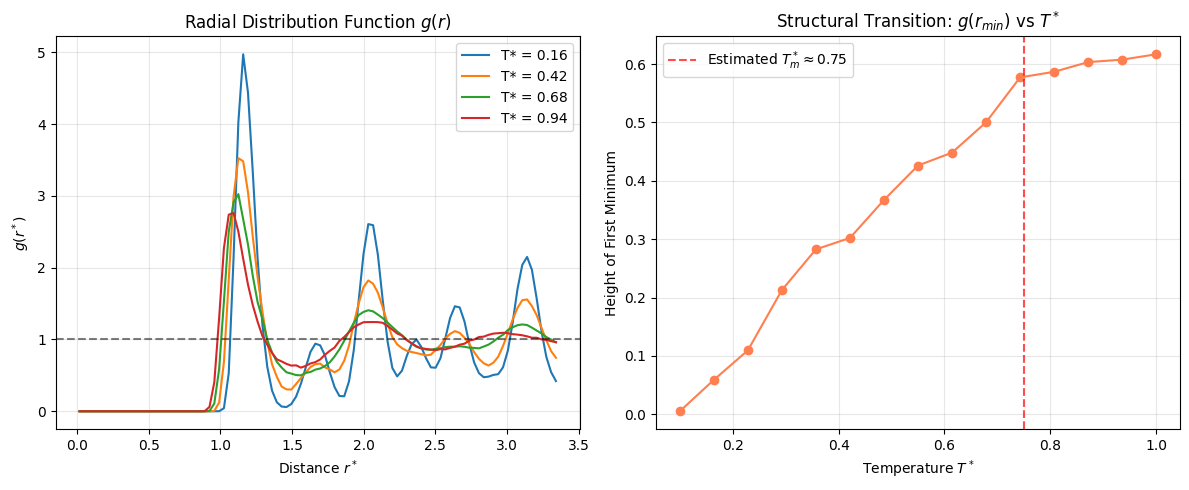

In [36]:
import numpy as np
import matplotlib.pyplot as plt


pos, L = generate_fcc_lattice(n_cells, rho_star)
N      = len(pos)

# Simulation Parameters
rebuild_threshold_sq = 0.25 * (r_skin - r_cutoff) ** 2
dt = 0.005
r_max = L / 2.0  
dr = r_max / 100.0  

# Use a finer temperature gradient to accurately spot the phase transition
temperatures = np.linspace(0.1, 1, 15) 
equilibration_steps = 1000
production_steps = 1000

# Arrays to store data for our melting point analysis
g_min_vs_T = []
r_centers_list = []
g_r_list = []

print("Starting Heating Process...")

for T_target in temperatures:
    print(f"Running simulation for T* = {T_target:.2f}...")
    
    # Initialize velocities for the new temperature step
    vel = initialize_velocities(N, T_target)
    neighbour_list = update_neighbor_list(pos, L, r_skin_sq)
    pe, force = calculate_forces_optimized(pos, neighbour_list, L, r_cutoff_sq)
    pos_ref = pos.copy()
    
    # 1. Equilibration Phase
    for step in range(equilibration_steps):
        pos, vel, pe, force = velocity_verlet_step_opt(pos, vel, force, dt, L, r_cutoff_sq, neighbour_list)
        
        disp_sq = np.sum((pos - pos_ref)**2, axis=1)
        if np.any(disp_sq > rebuild_threshold_sq):
            neighbour_list = update_neighbor_list(pos, L, r_skin_sq)
            pos_ref = pos.copy()
            
        if step % 10 == 0:
            vel = rescale_velocities(vel, T_target)

    # 2. Production Phase
    g_r_accumulated = np.zeros(int(r_max/dr))
    collection_count = 0
    
    for step in range(production_steps):
        pos, vel, pe, force = velocity_verlet_step_opt(pos, vel, force, dt, L, r_cutoff_sq, neighbour_list)
        
        disp_sq = np.sum((pos - pos_ref)**2, axis=1)
        if np.any(disp_sq > rebuild_threshold_sq):
            neighbour_list = update_neighbor_list(pos, L, r_skin_sq)
            pos_ref = pos.copy()
            
        if step % 10 == 0:
            r_centers, g_r_current = calculate_rdf(pos, L, dr, r_max)
            g_r_accumulated += g_r_current
            collection_count += 1
            
    # Process Production Data
    g_r_avg = g_r_accumulated / collection_count
    g_r_list.append(g_r_avg)
    r_centers_list = r_centers # x-axis is identical for all runs
    
    # Isolate the first minimum in g(r) (typically between 1.2 and 1.8 for LJ systems)
    search_indices = np.where((r_centers > 1.2) & (r_centers < 1.8))[0]
    if len(search_indices) > 0:
        first_min = np.min(g_r_avg[search_indices])
    else:
        first_min = 0
    g_min_vs_T.append(first_min)


# --- PLOTTING THE RESULTS ---
fig, axs = plt.subplots(1, 2, figsize=(12, 5)) 

# Plot 1: Standard g(r) overlapping (Displaying a subset to avoid clutter)
plot_indices = [1, 5, 9, 13] 
for idx in plot_indices:
    axs[0].plot(r_centers_list, g_r_list[idx], label=f'T* = {temperatures[idx]:.2f}')
axs[0].set_title('Radial Distribution Function $g(r)$')
axs[0].set_xlabel('Distance $r^*$')
axs[0].set_ylabel('$g(r^*)$')
axs[0].axhline(1.0, color='black', linestyle='--', alpha=0.5)
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Plot 2: Structural Metric - First Minimum of g(r)
axs[1].plot(temperatures, g_min_vs_T, marker='o', color='coral', linestyle='-')
axs[1].set_title('Structural Transition: $g(r_{min})$ vs $T^*$')
axs[1].set_xlabel('Temperature $T^*$')
axs[1].set_ylabel('Height of First Minimum')
axs[1].grid(True, alpha=0.3)

estimated_Tm = 0.75
axs[1].axvline(estimated_Tm, color='red', linestyle='--', alpha=0.7, label=f'Estimated $T_m^* \\approx {estimated_Tm}$')
axs[1].legend()

plt.tight_layout()
plt.show()

Running simulation for T* = 0.1...


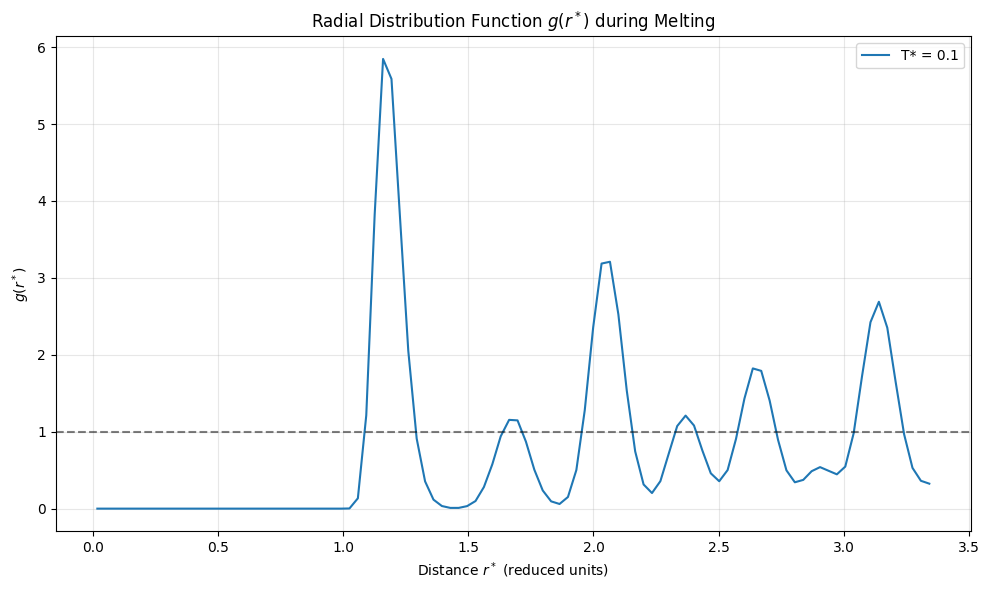

In [53]:
# Determining Coordination Number and confirming Maxima correspond to the peaks of FCC Lattice
n_cells     = 4
rho_star    = 0.8442
T_target    = 1.0
dt          = 0.005
total_steps = 2000
r_cutoff    = 2.5
r_cutoff_sq = r_cutoff ** 2
r_skin      = 3.2
r_skin_sq   = r_skin ** 2

pos, L = generate_fcc_lattice(n_cells, rho_star)
N      = len(pos)
vel    = initialize_velocities(N, T_target)

neighbour_list   = update_neighbor_list(pos, L, r_skin_sq)
pe, force        = calculate_forces_optimized(pos, neighbour_list, L, r_cutoff_sq)
pos_ref          = pos.copy()
rebuild_threshold_sq = 0.25 * (r_skin - r_cutoff) ** 2
temperatures = [0.1]
equilibration_steps = 1000
production_steps = 1000
dt = 0.005
r_max = L / 2.0  # Max distance is half the box length
dr = r_max / 100.0  # 100 bins

plt.figure(figsize=(10, 6))


for T_target in temperatures:
    print(f"Running simulation for T* = {T_target}...")
    
    # Re-initialize for each temperature run to simulate the stepping process 
    # (or you can carry the positions over to naturally melt it, but scaling velocities is safer here)
    vel = initialize_velocities(N, T_target)
    neighbour_list = update_neighbor_list(pos, L, r_skin_sq)
    pe, force = calculate_forces_optimized(pos, neighbour_list, L, r_cutoff_sq)
    
    # 1. Equilibration Phase
    for step in range(equilibration_steps):
        pos, vel, pe, force = velocity_verlet_step_opt(pos, vel, force, dt, L, r_cutoff_sq, neighbour_list)
        
        # Update neighbor list if atoms moved too far
        disp_sq = np.sum((pos - pos_ref)**2, axis=1)
        if np.any(disp_sq > rebuild_threshold_sq):
            neighbour_list = update_neighbor_list(pos, L, r_skin_sq)
            pos_ref = pos.copy()
            
        # Velocity rescaling thermostat
        if step % 10 == 0:
            vel = rescale_velocities(vel, T_target)

    # 2. Production Phase (Collect g(r) data)
    g_r_accumulated = np.zeros(int(r_max/dr))
    collection_count = 0
    
    for step in range(production_steps):
        pos, vel, pe, force = velocity_verlet_step_opt(pos, vel, force, dt, L, r_cutoff_sq, neighbour_list)
        
        disp_sq = np.sum((pos - pos_ref)**2, axis=1)
        if np.any(disp_sq > rebuild_threshold_sq):
            neighbour_list = update_neighbor_list(pos, L, r_skin_sq)
            pos_ref = pos.copy()
            
        # Collect g(r) periodically to avoid highly correlated data (e.g., every 10 steps)
        if step % 10 == 0:
            r_centers, g_r_current = calculate_rdf(pos, L, dr, r_max)
            g_r_accumulated += g_r_current
            collection_count += 1
            
    # Average the collected g(r) data
    g_r_avg = g_r_accumulated / collection_count
    
    # Plot this temperature's g(r)
    # NOTE: Before final submission, multiply r_centers by your chosen gas's sigma (in Å)
    plt.plot(r_centers, g_r_avg, label=f'T* = {T_target}')

# Finalize the plot
plt.title('Radial Distribution Function $g(r^*)$ during Melting')
plt.xlabel('Distance $r^*$ (reduced units)')
plt.ylabel('$g(r^*)$')
plt.axhline(1.0, color='black', linestyle='--', alpha=0.5) # Asymptote reference line
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [56]:
n = 5
temp = n
peak_indx_list = np.zeros(n, dtype=int)
first_peak_idx = 0
second_peak_idx = 0
first_n_maxima = []
j = 0
for i in range(1, len(g_r_avg)-1):
    if((g_r_avg[i] >= g_r_avg[i-1] and g_r_avg[i] > g_r_avg[i+1]) or (g_r_avg[i] > g_r_avg[i-1] and g_r_avg[i] >= g_r_avg[i+1])):
        first_n_maxima.append(r_centers[i])
        if(peak_indx_list[j] == 0): 
            peak_indx_list[j] = i
            j += 1
        temp -= 1
        if(temp==0): break
print(first_n_maxima)
a = L/n_cells
a_arr = np.array([a*np.sqrt(i/2) for i in range(1, n+1)])
print(a_arr/a_arr[0])
print(first_n_maxima/first_n_maxima[0])
print(peak_indx_list)

[np.float64(1.1589213720539298), np.float64(1.662800229468682), np.float64(2.0659033154004836), np.float64(2.368230629849335), np.float64(2.636966020470536)]
[1.         1.41421356 1.73205081 2.         2.23606798]
[1.         1.43478261 1.7826087  2.04347826 2.27536232]
[34 49 61 70 78]


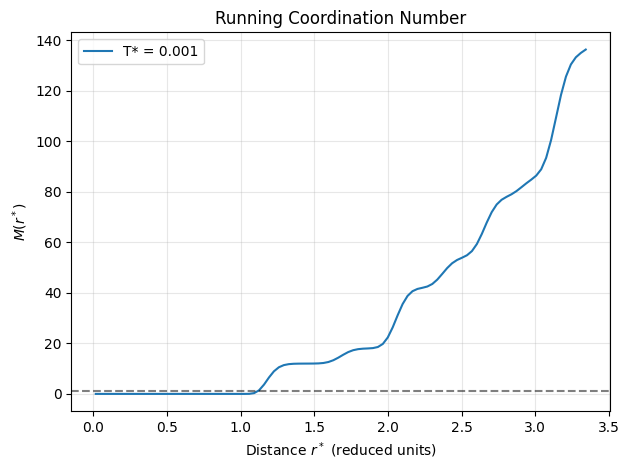

[ 0 42 55 66 74 83]
5
1st Minimum at r* = 1.43
Coordination Number: 11.995976562499996
2nd Minimum at r* = 1.86
Coordination Number: 6.0021093749999945
3rd Minimum at r* = 2.23
Coordination Number: 24.006015625000007
4rd Minimum at r* = 2.50
Coordination Number: 11.899921874999983
5rd Minimum at r* = 2.80
Coordination Number: 24.09988281249999


In [57]:
# first_peak_idx = np.argmax(g_r_avg)

# 2. Start the search for the minimum AFTER that peak
min_indx_list = np.zeros(n,dtype=int)
first_min_idx = 0
second_min_idx = 0
for j in range(n):
    for i in range(peak_indx_list[j], len(g_r_avg) - 1):
        if((g_r_avg[i] <= g_r_avg[i-1] and g_r_avg[i] < g_r_avg[i+1]) or (g_r_avg[i] < g_r_avg[i-1] and g_r_avg[i] <= g_r_avg[i+1])):
            min_indx_list[j] = i
            break

# 3. Integrate up to that index
integrand = 4 * np.pi * rho_star * (r_centers**2) * g_r_avg
coordination_number = np.array([np.trapezoid(integrand[0 : i + 1], r_centers[0 : i + 1]) for i in range(len(r_centers))])
# print(coordination_number)
plt.plot(r_centers, coordination_number, label=f'T* = 0.001')
# Finalize the plot
plt.title('Running Coordination Number')
plt.xlabel('Distance $r^*$ (reduced units)')
plt.ylabel('$M(r^*)$')
plt.axhline(1.0, color='black', linestyle='--', alpha=0.5) # Asymptote reference line
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
min_indx_list = np.insert(min_indx_list, 0, 0)
print(min_indx_list)
print(n)
coord_numbers = np.array([coordination_number[min_indx_list[i+1]] - coordination_number[min_indx_list[i]] for i in range(n)])
first_coordination_number = coordination_number[first_min_idx] - coordination_number[0]
second_coordination_number = coordination_number[second_min_idx] - coordination_number[first_min_idx]
st = "th"
for i in range(n):
    ist = i+1
    if(ist%10 == 1): st = "st"
    elif(ist%10 == 2): st = "nd"
    elif(ist%10 == 3): st = "rd"
    print(f"{ist}{st} Minimum at r* = {r_centers[min_indx_list[i+1]]:.2f}")
    print(f"Coordination Number: {coord_numbers[i]}")